PACKAGE 9.1 : COMPLETE MODEL COMPARISON


MODEL COMPARISON
   Rank                          Model     RMSE      MAE      R2
0     1                        XGBoost   28.180   21.586  0.8966
1     2                       LightGBM   28.509   21.764  0.8942
2     3                  Random Forest   29.610   22.272  0.8858
3     4  Persistence (AQI_t = AQI_t-1)   39.670   29.324  0.7951
4     5                  Mean Baseline  123.045  110.281 -0.9716


BEST MODEL
Model : XGBoost
RMSE  : 28.180
MAE   : 21.586
R²    : 0.8966

Improvement over Persistence Baseline:
28.96%


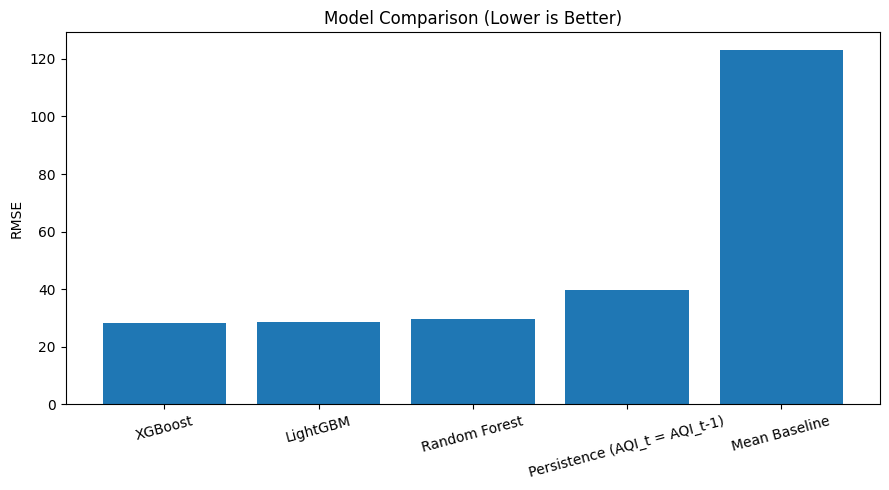

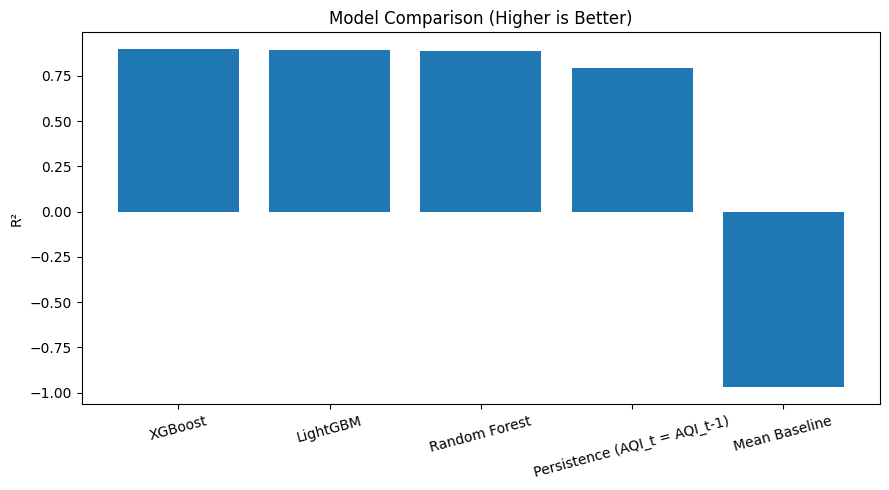


Saved Files:
1. Complete_Model_Comparison.csv
2. Best_Model_Summary.csv
3. Model_Comparison_RMSE.png
4. Model_Comparison_R2.png

Package 9.1 Completed Successfully.


In [1]:
# ============================================================
# PACKAGE 9.1
# COMPLETE MODEL COMPARISON & BEST MODEL SELECTION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 75)
print("PACKAGE 9.1 : COMPLETE MODEL COMPARISON")
print("=" * 75)

# ------------------------------------------------------------
# Load Results
# ------------------------------------------------------------

baseline = pd.read_csv(r"C:\Users\91863\Desktop\AIR QUALITY INTELLIGENCE\Forecasting Model Pipeline\Baseline_RF_X\Basline_Models\Baseline_Model_Results.csv")
rf = pd.read_csv(r"C:\Users\91863\Desktop\AIR QUALITY INTELLIGENCE\Forecasting Model Pipeline\Baseline_RF_X\Random_Forest_Regressor\RandomForest_Performance.csv")
xgb = pd.read_csv(r"C:\Users\91863\Desktop\AIR QUALITY INTELLIGENCE\Forecasting Model Pipeline\Baseline_RF_X\XGBoost\XGBoost_Performance.csv")
lgbm = pd.read_csv(r"C:\Users\91863\Desktop\AIR QUALITY INTELLIGENCE\Forecasting Model Pipeline\Baseline_RF_X\LightGBM\LightGBM_Performance.csv")

# ------------------------------------------------------------
# Merge Results
# ------------------------------------------------------------

comparison = pd.concat(
    [
        baseline,
        rf,
        xgb,
        lgbm
    ],
    ignore_index=True
)

comparison = comparison.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

# ------------------------------------------------------------
# Rank Models
# ------------------------------------------------------------

comparison["Rank"] = range(1, len(comparison)+1)

comparison = comparison[
    [
        "Rank",
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
]

print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison)

# ------------------------------------------------------------
# Best Model
# ------------------------------------------------------------

best_model = comparison.iloc[0]

print("\n")
print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model : {best_model['Model']}")
print(f"RMSE  : {best_model['RMSE']:.3f}")
print(f"MAE   : {best_model['MAE']:.3f}")
print(f"R²    : {best_model['R2']:.4f}")

# ------------------------------------------------------------
# Improvement over Persistence Baseline
# ------------------------------------------------------------

baseline_rmse = comparison.loc[
    comparison["Model"]=="Persistence (AQI_t = AQI_t-1)",
    "RMSE"
].values[0]

improvement = (
    (baseline_rmse-best_model["RMSE"])
    / baseline_rmse
)*100

print("\nImprovement over Persistence Baseline:")
print(f"{improvement:.2f}%")

# ------------------------------------------------------------
# Save Comparison
# ------------------------------------------------------------

comparison.to_csv(
    "Complete_Model_Comparison.csv",
    index=False
)

# ------------------------------------------------------------
# RMSE Comparison Plot
# ------------------------------------------------------------

plt.figure(figsize=(9,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Model Comparison (Lower is Better)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "Model_Comparison_RMSE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# R² Comparison Plot
# ------------------------------------------------------------

plt.figure(figsize=(9,5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.ylabel("R²")
plt.title("Model Comparison (Higher is Better)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "Model_Comparison_R2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Summary Report
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Metric":[
        "Best Model",
        "Best RMSE",
        "Best MAE",
        "Best R2",
        "Improvement_vs_Persistence(%)"
    ],

    "Value":[
        best_model["Model"],
        best_model["RMSE"],
        best_model["MAE"],
        best_model["R2"],
        round(improvement,2)
    ]

})

summary.to_csv(
    "Best_Model_Summary.csv",
    index=False
)

print("\nSaved Files:")
print("1. Complete_Model_Comparison.csv")
print("2. Best_Model_Summary.csv")
print("3. Model_Comparison_RMSE.png")
print("4. Model_Comparison_R2.png")

print("\nPackage 9.1 Completed Successfully.")